# Federated Learning Results Analysis
## Statistical Analysis of FL Algorithms (FedAvg, FedProx, Scaffold, FedDyn, FedOpt,pFedMe UniCSL)

This notebook analyzes experimental results from 5 seeds across three scenarios:
- **IID**: Independent and Identically Distributed data
- **Non-IID**: Non-Independent and Identically Distributed data  
- **Non-IID Corrupted**: Non-IID data with label corruption

The analysis includes:
1. Loading and aggregating results from all seeds
2. Computing mean ± std for each algorithm
3. Performing paired t-tests between algorithms
4. Final results table with statistics and p-values

In [23]:
# Import Required Libraries
import pandas as pd
import numpy as np
from scipy import stats
import os
import glob
import warnings

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1: Load and Explore Data
Load all experiment result files (5 seeds) and display sample data

In [24]:
# Define paths and seeds
current_dir = r'/Users/mlsilab/Documents/Shuvo/UniCSL/results/revision 3 sq hinge'
seeds = [1, 12, 123, 1234, 42]
scenarios = ['iid', 'non_iid', 'non_iid_corrupted']

# Algorithm column names
algorithms = {
    'fedavg': 'fedavg_sq_hinge',
    'fedprox': 'fedprox_sq_hinge',
    'scaffold': 'scaffold_sq_hinge',
    'feddyn': 'feddyn_sq_hinge',
    'fedopt': 'fedopt_sq_hinge',
    'pfedme': 'pfedme_sq_hinge',
    'unicsl': 'unicsl_static'
}

# Load data from all seeds
data_all_seeds = {scenario: {} for scenario in scenarios}

for scenario in scenarios:
    for seed in seeds:
        file_path = os.path.join(current_dir, f'{seed}_experimental_results.xlsx')
        try:
            df = pd.read_excel(file_path, sheet_name=scenario)
            data_all_seeds[scenario][seed] = df
            print(f"✓ Loaded seed {seed} - {scenario}: shape {df.shape}")
        except Exception as e:
            print(f"✗ Error loading seed {seed} - {scenario}: {e}")

print(f"\n✓ Successfully loaded data for all {len(seeds)} seeds")

# Display sample data
print("\n" + "="*80)
print("SAMPLE DATA (Seed 1, IID Scenario):")
print("="*80)
sample_df = data_all_seeds['iid'][1]
print(f"\nShape: {sample_df.shape}")
print(f"\nColumn names: {list(sample_df.columns)}")
print(f"\nFirst 5 rows:")
print(sample_df.head())

✓ Loaded seed 1 - iid: shape (255, 10)
✓ Loaded seed 12 - iid: shape (255, 10)
✓ Loaded seed 123 - iid: shape (255, 10)
✓ Loaded seed 1234 - iid: shape (255, 10)
✓ Loaded seed 42 - iid: shape (255, 10)
✓ Loaded seed 1 - non_iid: shape (255, 10)
✓ Loaded seed 12 - non_iid: shape (255, 10)
✓ Loaded seed 123 - non_iid: shape (255, 10)
✓ Loaded seed 1234 - non_iid: shape (255, 10)
✓ Loaded seed 42 - non_iid: shape (255, 10)
✓ Loaded seed 1 - non_iid_corrupted: shape (255, 10)
✓ Loaded seed 12 - non_iid_corrupted: shape (255, 10)
✓ Loaded seed 123 - non_iid_corrupted: shape (255, 10)
✓ Loaded seed 1234 - non_iid_corrupted: shape (255, 10)
✓ Loaded seed 42 - non_iid_corrupted: shape (255, 10)

✓ Successfully loaded data for all 5 seeds

SAMPLE DATA (Seed 1, IID Scenario):

Shape: (255, 10)

Column names: ['Config', 'Dataset', 'Round', 'fedavg_sq_hinge', 'fedprox_sq_hinge', 'scaffold_sq_hinge', 'feddyn_sq_hinge', 'fedopt_sq_hinge', 'pfedme_sq_hinge', 'unicsl_static']

First 5 rows:
          

## Section 2: Aggregate Results Across Seeds
Combine results from all 5 seed experiments for each scenario

In [25]:
# Aggregate results: organize by scenario, dataset, and algorithm
# Structure: {scenario: {dataset: {algo: [seed_values]}}}
# IMPORTANT: Exclude 'Average' row, only use rounds 1-50
aggregated_data = {}

for scenario in scenarios:
    aggregated_data[scenario] = {}
    
    for seed in seeds:
        df = data_all_seeds[scenario][seed]
        
        # Group by dataset
        for dataset_name in df['Dataset'].unique():
            if dataset_name not in aggregated_data[scenario]:
                aggregated_data[scenario][dataset_name] = {algo: [] for algo in algorithms.keys()}
            
            dataset_df = df[df['Dataset'] == dataset_name]
            
            # FILTER: Only include rounds 1-50, exclude 'Average' row
            dataset_df = dataset_df[dataset_df['Round'] != 'Average']
            
            # For each algorithm
            for algo_name, col_name in algorithms.items():
                if col_name in dataset_df.columns:
                    values = dataset_df[col_name].dropna().values
                    # Store AVERAGE of rounds 1-50 per seed for each dataset
                    aggregated_data[scenario][dataset_name][algo_name].append(values.mean())

print("Data Aggregation Summary:")
print("="*80)
for scenario in scenarios:
    datasets = list(aggregated_data[scenario].keys())
    print(f"\n{scenario.upper()}:")
    print(f"  Datasets: {', '.join(sorted(datasets))}")
    print(f"  Number of datasets: {len(datasets)}")
    print(f"  Seeds per dataset: {len(seeds)}")
    print(f"  Rounds per dataset per seed: 50 (excluding 'Average' row)")

Data Aggregation Summary:

IID:
  Datasets: A9a, Run_or_walk_information, hepmass, magic_gamma_telescope, susy
  Number of datasets: 5
  Seeds per dataset: 5
  Rounds per dataset per seed: 50 (excluding 'Average' row)

NON_IID:
  Datasets: A9a, Run_or_walk_information, hepmass, magic_gamma_telescope, susy
  Number of datasets: 5
  Seeds per dataset: 5
  Rounds per dataset per seed: 50 (excluding 'Average' row)

NON_IID_CORRUPTED:
  Datasets: A9a, Run_or_walk_information, hepmass, magic_gamma_telescope, susy
  Number of datasets: 5
  Seeds per dataset: 5
  Rounds per dataset per seed: 50 (excluding 'Average' row)


## Section 3: Calculate Statistics for Each Algorithm
Compute mean and standard deviation across seeds

In [26]:
# Calculate mean and std for each algorithm across seeds, PER DATASET
# Structure: {scenario: {dataset: {algo: {mean, std, seed_means}}}}
statistics = {scenario: {} for scenario in scenarios}

for scenario in scenarios:
    for dataset_name in aggregated_data[scenario].keys():
        statistics[scenario][dataset_name] = {}
        
        for algo_name in algorithms.keys():
            # Get seed means for this dataset and algorithm
            seed_means = aggregated_data[scenario][dataset_name][algo_name]
            
            if seed_means and len(seed_means) > 0:
                overall_mean = np.mean(seed_means)
                overall_std = np.std(seed_means)
                
                statistics[scenario][dataset_name][algo_name] = {
                    'mean': overall_mean,
                    'std': overall_std,
                    'seed_means': seed_means  # Store for t-test
                }

print("Statistics Calculated (Per Dataset):")
print("="*100)
for scenario in scenarios:
    print(f"\n{scenario.upper()}:")
    for dataset_name in sorted(aggregated_data[scenario].keys()):
        print(f"\n  Dataset: {dataset_name}")
        print(f"  {'Algorithm':<15} {'Mean':>10} {'Std':>10} {'Format':>20}")
        print("  " + "-" * 70)
        for algo in algorithms.keys():
            if algo in statistics[scenario][dataset_name]:
                stats_dict = statistics[scenario][dataset_name][algo]
                mean = stats_dict['mean']
                std = stats_dict['std']
                formatted = f"{mean:.2f}±{std:.2f}"
                print(f"  {algo:<15} {mean:>10.2f} {std:>10.2f} {formatted:>20}")

Statistics Calculated (Per Dataset):

IID:

  Dataset: A9a
  Algorithm             Mean        Std               Format
  ----------------------------------------------------------------------
  fedavg               83.21       0.34           83.21±0.34
  fedprox              83.13       0.35           83.13±0.35
  scaffold             83.22       0.41           83.22±0.41
  feddyn               83.48       0.27           83.48±0.27
  fedopt               76.11       0.72           76.11±0.72
  pfedme               82.47       0.33           82.47±0.33
  unicsl               84.35       0.18           84.35±0.18

  Dataset: Run_or_walk_information
  Algorithm             Mean        Std               Format
  ----------------------------------------------------------------------
  fedavg               71.36       0.66           71.36±0.66
  fedprox              70.72       0.67           70.72±0.67
  scaffold             71.31       0.63           71.31±0.63
  feddyn               71.6

## Section 4: Perform Paired T-Tests
Compare each algorithm against UniCSL (proposed method) using paired t-tests

In [27]:
# Perform paired t-tests PER DATASET
# Compare each algorithm against UNICSL for each dataset

ttest_results = {scenario: {} for scenario in scenarios}

for scenario in scenarios:
    ttest_results[scenario] = {dataset: {} for dataset in aggregated_data[scenario].keys()}
    
    print(f"\n{'='*100}")
    print(f"PAIRED T-TEST RESULTS - {scenario.upper()}")
    print(f"{'='*100}")
    
    for dataset_name in sorted(aggregated_data[scenario].keys()):
        print(f"\n  Dataset: {dataset_name}")
        print(f"  {'Algorithm':<15} {'vs':<8} {'UniCSL':<10} {'t-value':>12} {'p-value':>12}")
        print("  " + "-" * 80)
        
        # Reference is UniCSL
        unicsl_seed_means = statistics[scenario][dataset_name]['unicsl']['seed_means']
        
        for algo in algorithms.keys():
            if algo != 'unicsl':
                algo_seed_means = statistics[scenario][dataset_name][algo]['seed_means']
                
                # Paired t-test
                if len(algo_seed_means) == len(unicsl_seed_means):
                    t_stat, p_val = stats.ttest_rel(algo_seed_means, unicsl_seed_means)
                    ttest_results[scenario][dataset_name][algo] = {
                        't_value': t_stat,
                        'p_value': p_val
                    }
                    print(f"  {algo:<15} {'vs':<8} {'UniCSL':<10} {t_stat:>12.4f} {p_val:>12.6f}")
                else:
                    print(f"  {algo:<15} {'vs':<8} {'UniCSL':<10} {'MISMATCH':<12} {'MISMATCH':<12}")
        
        # Also add UniCSL results (t=0, p=1)
        ttest_results[scenario][dataset_name]['unicsl'] = {
            't_value': 0.0,
            'p_value': 1.0
        }


PAIRED T-TEST RESULTS - IID

  Dataset: A9a
  Algorithm       vs       UniCSL          t-value      p-value
  --------------------------------------------------------------------------------
  fedavg          vs       UniCSL          -7.7898     0.001465
  fedprox         vs       UniCSL          -8.0813     0.001274
  scaffold        vs       UniCSL          -5.7480     0.004541
  feddyn          vs       UniCSL          -5.8901     0.004154
  fedopt          vs       UniCSL         -22.4893     0.000023
  pfedme          vs       UniCSL         -12.2348     0.000256

  Dataset: Run_or_walk_information
  Algorithm       vs       UniCSL          t-value      p-value
  --------------------------------------------------------------------------------
  fedavg          vs       UniCSL         -34.4516     0.000004
  fedprox         vs       UniCSL         -36.1022     0.000004
  scaffold        vs       UniCSL         -35.9752     0.000004
  feddyn          vs       UniCSL         -44.017

## Section 5: Format Results Table
Create final DataFrame with statistics and p-values formatted as requested

In [28]:
# Create formatted results dataframe PER DATASET
# Format: each algorithm has 2 rows: mean±std and (t-value, p-value)

def format_results_table_per_dataset(scenarios, statistics, ttest_results, aggregated_data):
    """
    Create a formatted DataFrame with results displayed as:
    - Row 1: algorithm_name (mean±std)
    - Row 2: (t-value, p-value)
    Organized per dataset
    """
    
    all_results = {}
    
    for scenario in scenarios:
        all_results[scenario] = {}
        
        for dataset_name in sorted(aggregated_data[scenario].keys()):
            dataset_data = {}
            
            for algo in algorithms.keys():
                # Get statistics
                stats_dict = statistics[scenario][dataset_name][algo]
                mean = stats_dict['mean']
                std = stats_dict['std']
                stats_str = f"{mean:.2f}±{std:.2f}"
                
                # Get t-test results
                t_val = ttest_results[scenario][dataset_name][algo]['t_value']
                p_val = ttest_results[scenario][dataset_name][algo]['p_value']
                
                # Format p-value: show "<0.001" if p < 0.001
                p_val_str = "<0.001" if p_val < 0.001 else f"{p_val:.3f}"
                pval_str = f"({t_val:.2f}, {p_val_str})"
                
                # Store both lines for this algorithm
                dataset_data[f"{algo}_stat"] = stats_str
                dataset_data[f"{algo}_pval"] = pval_str
            
            all_results[scenario][dataset_name] = dataset_data
    
    return all_results

# Format results
formatted_results = format_results_table_per_dataset(scenarios, statistics, ttest_results, aggregated_data)

# Create display DataFrames for each scenario and dataset
for scenario in scenarios:
    print(f"\n{'='*120}")
    print(f"FINAL RESULTS TABLE - {scenario.upper()}")
    print(f"{'='*120}\n")
    
    for dataset_name in sorted(aggregated_data[scenario].keys()):
        print(f"\n  Dataset: {dataset_name}")
        print(f"  {'-'*110}")
        
        # Create a DataFrame for display
        result_dict = {'Metric': []}
        for algo in algorithms.keys():
            result_dict[algo] = []
        
        # Row 1: mean±std
        result_dict['Metric'].append('Mean±Std')
        for algo in algorithms.keys():
            result_dict['Metric'].append(formatted_results[scenario][dataset_name][f"{algo}_stat"])
        
        # Row 2: (t-value, p-value)
        result_dict['Metric'].append('(t-val, p-val) vs UniCSL')
        for algo in algorithms.keys():
            result_dict['Metric'].append(formatted_results[scenario][dataset_name][f"{algo}_pval"])
        
        # Print in two rows per dataset
        print(f"  Mean±Std:              {', '.join([formatted_results[scenario][dataset_name][f'{algo}_stat'] for algo in algorithms.keys()])}")
        print(f"  (t-val, p-val):        {', '.join([formatted_results[scenario][dataset_name][f'{algo}_pval'] for algo in algorithms.keys()])}")
        print()

print("\n" + "="*120)
print("INTERPRETATION GUIDE")
print("="*120)
print("""
- Mean±Std: Average accuracy across 5 seeds ± standard deviation (per dataset)
- (t-value, p-value): Results of paired t-test comparing each algorithm against UniCSL
  - p-value < 0.05: Statistically significant difference
  - p-value >= 0.05: No significant difference
  - t-value > 0: Algorithm performance > UniCSL
  - t-value < 0: Algorithm performance < UniCSL
""")


FINAL RESULTS TABLE - IID


  Dataset: A9a
  --------------------------------------------------------------------------------------------------------------
  Mean±Std:              83.21±0.34, 83.13±0.35, 83.22±0.41, 83.48±0.27, 76.11±0.72, 82.47±0.33, 84.35±0.18
  (t-val, p-val):        (-7.79, 0.001), (-8.08, 0.001), (-5.75, 0.005), (-5.89, 0.004), (-22.49, <0.001), (-12.23, <0.001), (0.00, 1.000)


  Dataset: Run_or_walk_information
  --------------------------------------------------------------------------------------------------------------
  Mean±Std:              71.36±0.66, 70.72±0.67, 71.31±0.63, 71.63±0.52, 69.26±0.61, 67.21±0.74, 84.49±0.26
  (t-val, p-val):        (-34.45, <0.001), (-36.10, <0.001), (-35.98, <0.001), (-44.02, <0.001), (-46.87, <0.001), (-47.16, <0.001), (0.00, 1.000)


  Dataset: hepmass
  --------------------------------------------------------------------------------------------------------------
  Mean±Std:              90.53±0.11, 90.44±0.11, 90.53±0.

## Section 6: Display Final Results
Comprehensive summary of all results across scenarios

In [29]:
# Export results to Excel - wide format matching LaTeX table layout
# Each row = one dataset, each column = one algorithm
# Cell content = "mean ± std\n(t-val, p-val)"

output_dir = r'/Users/mlsilab/Documents/Shuvo/UniCSL/results/revision 3 sq hinge'
output_file = os.path.join(output_dir, 'Federated_Learning_Results.xlsx')

algo_display_names = {
    'fedavg': 'FedAvg',
    'fedprox': 'FedProx',
    'scaffold': 'SCAFFOLD',
    'feddyn': 'FedDyn',
    'fedopt': 'FedOpt',
    'pfedme': 'pFedMe',
    'unicsl': 'UniCSL'
}

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    
    for scenario in scenarios:
        rows = []
        
        for dataset_name in sorted(aggregated_data[scenario].keys()):
            row = {'Dataset': dataset_name}
            
            for algo in algorithms.keys():
                stats_str = formatted_results[scenario][dataset_name][f"{algo}_stat"].replace("±", " ± ")
                
                if algo == 'unicsl':
                    # UniCSL: bold, no t-test cell
                    row[algo_display_names[algo]] = stats_str
                else:
                    pval_str = formatted_results[scenario][dataset_name][f"{algo}_pval"]
                    # Multi-line cell: "mean ± std\n(t-val, p-val)"
                    row[algo_display_names[algo]] = f"{stats_str}\n{pval_str}"
            
            rows.append(row)
        
        scenario_df = pd.DataFrame(rows)
        scenario_df.to_excel(writer, sheet_name=scenario, index=False)
        
        # Auto-wrap text in cells so multi-line content is visible
        ws = writer.sheets[scenario]
        from openpyxl.styles import Alignment
        for row in ws.iter_rows():
            for cell in row:
                cell.alignment = Alignment(wrap_text=True, vertical='top')
        
        # Set column widths
        for col in ws.columns:
            ws.column_dimensions[col[0].column_letter].width = 28
        
        print(f"✓ Created sheet: {scenario}")

print(f"\n✓ Results exported to: {output_file}")

✓ Created sheet: iid
✓ Created sheet: non_iid
✓ Created sheet: non_iid_corrupted

✓ Results exported to: /Users/mlsilab/Documents/Shuvo/UniCSL/results/revision 3 sq hinge/Federated_Learning_Results.xlsx


In [30]:
# =============================================================================
# Mean Difference and 95% Confidence Interval (Baseline - UniCSL)
# =============================================================================

from scipy import stats
import numpy as np
import pandas as pd

ci_results = {scenario: {} for scenario in scenarios}

print("=" * 120)
print("MEAN DIFFERENCE AND 95% CONFIDENCE INTERVAL")
print("=" * 120)

for scenario in scenarios:

    ci_results[scenario] = {}

    print(f"\n{scenario.upper()}")
    print("-" * 120)
    print(f"{'Dataset':<12} {'Algorithm':<12} {'Mean Diff':>12} {'95% CI':>32}")

    for dataset_name in sorted(aggregated_data[scenario].keys()):

        ci_results[scenario][dataset_name] = {}

        # UniCSL seed means
        unicsl = np.array(statistics[scenario][dataset_name]['unicsl']['seed_means'])

        for algo in algorithms.keys():

            if algo == "unicsl":
                continue

            baseline = np.array(statistics[scenario][dataset_name][algo]['seed_means'])

            # Difference = Baseline - UniCSL
            diff = baseline - unicsl

            mean_diff = np.mean(diff)

            n = len(diff)
            se = stats.sem(diff)

            ci_low, ci_high = stats.t.interval(
                confidence=0.95,
                df=n-1,
                loc=mean_diff,
                scale=se
            )

            ci_results[scenario][dataset_name][algo] = {
                "mean_difference": mean_diff,
                "ci_lower": ci_low,
                "ci_upper": ci_high
            }

            print(
                f"{dataset_name:<12} "
                f"{algo:<12} "
                f"{mean_diff:>10.3f} "
                f"[{ci_low:.3f}, {ci_high:.3f}]"
            )


# =============================================================================
# Export Mean Difference + 95% Confidence Interval
# =============================================================================

algo_display_names = {
    'fedavg': 'FedAvg',
    'fedprox': 'FedProx',
    'scaffold': 'SCAFFOLD',
    'feddyn': 'FedDyn',
    'fedopt': 'FedOpt',
    'pfedme': 'pFedMe'
}

with pd.ExcelWriter(
    output_file,
    engine='openpyxl',
    mode='a',
    if_sheet_exists='replace'
) as writer:

    for scenario in scenarios:

        rows = []

        for dataset in sorted(ci_results[scenario].keys()):

            row = {"Dataset": dataset}

            for algo_key, algo_name in algo_display_names.items():

                result = ci_results[scenario][dataset][algo_key]

                row[algo_name] = (
                    f"{result['mean_difference']:.2f} "
                    f"({result['ci_lower']:.2f}, {result['ci_upper']:.2f})"
                )

            rows.append(row)

        df_ci = pd.DataFrame(rows)

        # Sheet names
        if scenario == "iid":
            sheet_name = "iid_CI"
        elif scenario == "non_iid":
            sheet_name = "non_iid_CI"
        elif scenario == "non_iid_corrupted":
            sheet_name = "non_iid_corrupted_CI"
        else:
            sheet_name = f"{scenario}_CI"

        df_ci.to_excel(writer, sheet_name=sheet_name, index=False)

print("✓ 95% confidence interval tables saved successfully.")

MEAN DIFFERENCE AND 95% CONFIDENCE INTERVAL

IID
------------------------------------------------------------------------------------------------------------------------
Dataset      Algorithm       Mean Diff                           95% CI
A9a          fedavg           -1.147 [-1.556, -0.738]
A9a          fedprox          -1.227 [-1.649, -0.806]
A9a          scaffold         -1.134 [-1.682, -0.586]
A9a          feddyn           -0.871 [-1.282, -0.461]
A9a          fedopt           -8.243 [-9.261, -7.225]
A9a          pfedme           -1.879 [-2.305, -1.452]
Run_or_walk_information fedavg          -13.133 [-14.191, -12.074]
Run_or_walk_information fedprox         -13.769 [-14.827, -12.710]
Run_or_walk_information scaffold        -13.181 [-14.198, -12.164]
Run_or_walk_information feddyn          -12.860 [-13.671, -12.049]
Run_or_walk_information fedopt          -15.228 [-16.130, -14.326]
Run_or_walk_information pfedme          -17.280 [-18.297, -16.262]
hepmass      fedavg            0

## Optional: Export Results to CSV
Save the comprehensive results to CSV files for further analysis or presentations

In [31]:
# # Export results to single Excel file with three sheets (one per scenario)
# output_dir = r'c:\Users\SSROY\Downloads\unicsl sq hinge results'
# output_file = os.path.join(output_dir, 'Federated_Learning_Results.xlsx')

# # Create Excel writer
# with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    
#     for scenario in scenarios:
#         # Combine all datasets for this scenario
#         scenario_data = []
        
#         for dataset_name in sorted(aggregated_data[scenario].keys()):
#             for algo_name, algo_data in comprehensive_results[scenario][dataset_name].items():
#                 scenario_data.append({
#                     'Dataset': dataset_name,
#                     'Algorithm': algo_name,
#                     'Mean±Std': algo_data['Mean±Std'],
#                     '(t-value, p-value)': algo_data['(t-value, p-value)']
#                 })
        
#         # Create DataFrame for this scenario
#         scenario_df = pd.DataFrame(scenario_data)
        
#         # Write to Excel sheet
#         scenario_df.to_excel(writer, sheet_name=scenario, index=False)
#         print(f"✓ Created sheet: {scenario}")

# print(f"\n✓ All results exported to: {output_file}")

✓ Saved: /Users/mlsilab/Documents/Shuvo/UniCSL/results/revision 3 sq hinge/convergence_iid_A9a.png


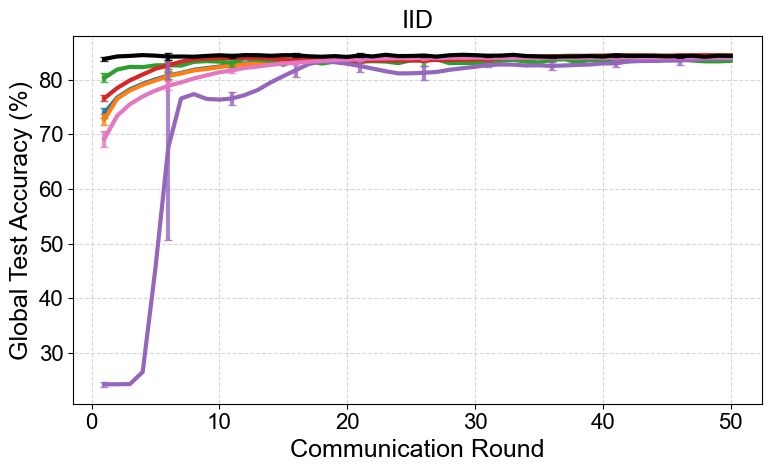

✓ Saved: /Users/mlsilab/Documents/Shuvo/UniCSL/results/revision 3 sq hinge/convergence_iid_Run_or_walk_information.png


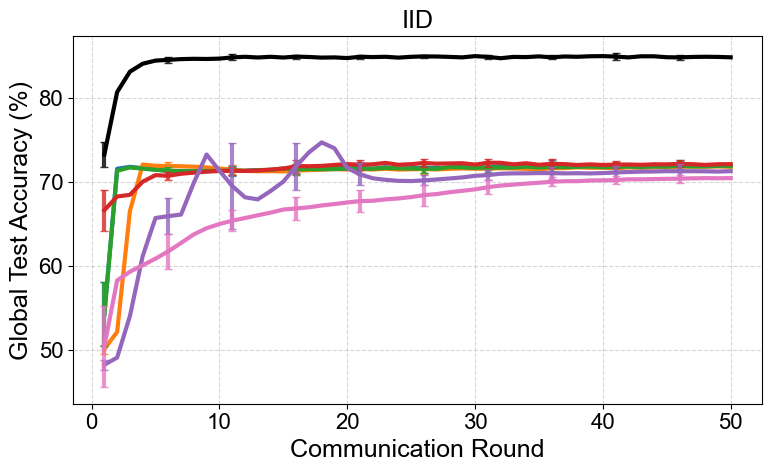

✓ Saved: /Users/mlsilab/Documents/Shuvo/UniCSL/results/revision 3 sq hinge/convergence_iid_hepmass.png


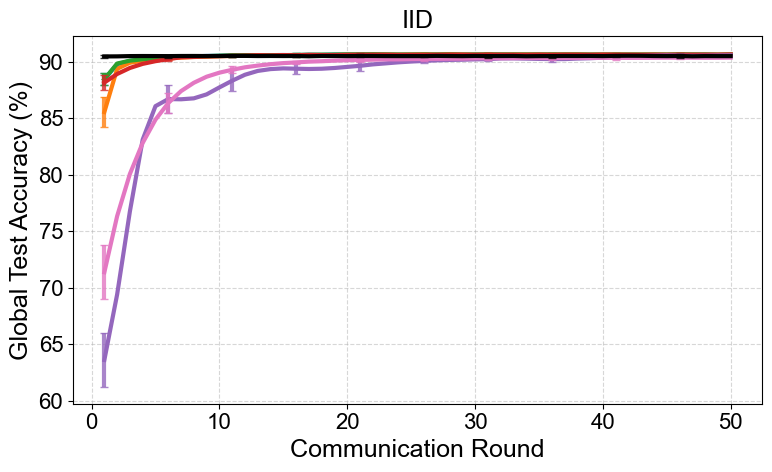

✓ Saved: /Users/mlsilab/Documents/Shuvo/UniCSL/results/revision 3 sq hinge/convergence_iid_magic_gamma_telescope.png


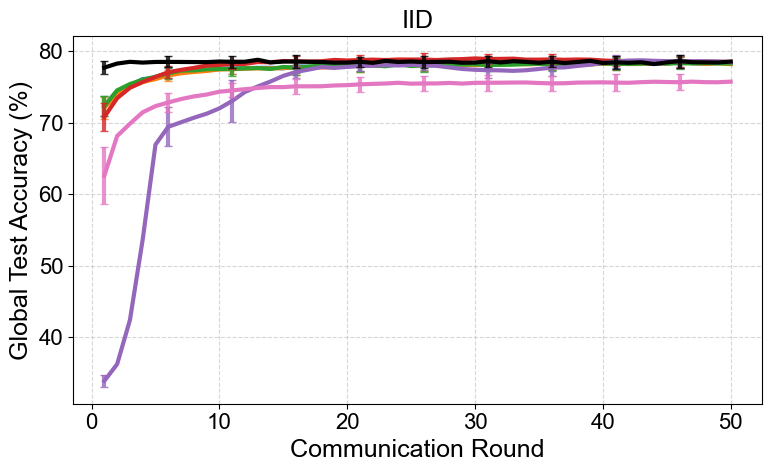

✓ Saved: /Users/mlsilab/Documents/Shuvo/UniCSL/results/revision 3 sq hinge/convergence_iid_susy.png


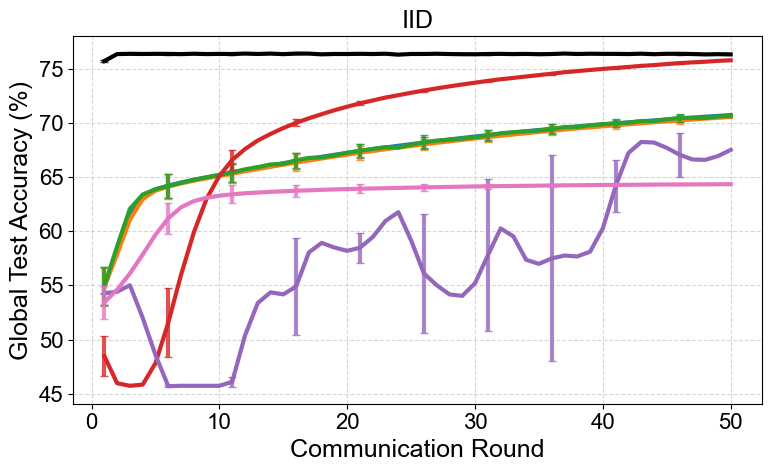

✓ Saved: /Users/mlsilab/Documents/Shuvo/UniCSL/results/revision 3 sq hinge/convergence_non_iid_A9a.png


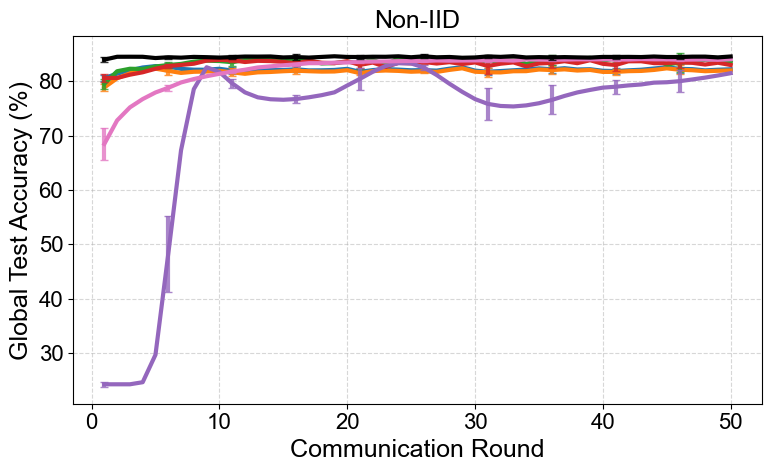

✓ Saved: /Users/mlsilab/Documents/Shuvo/UniCSL/results/revision 3 sq hinge/convergence_non_iid_Run_or_walk_information.png


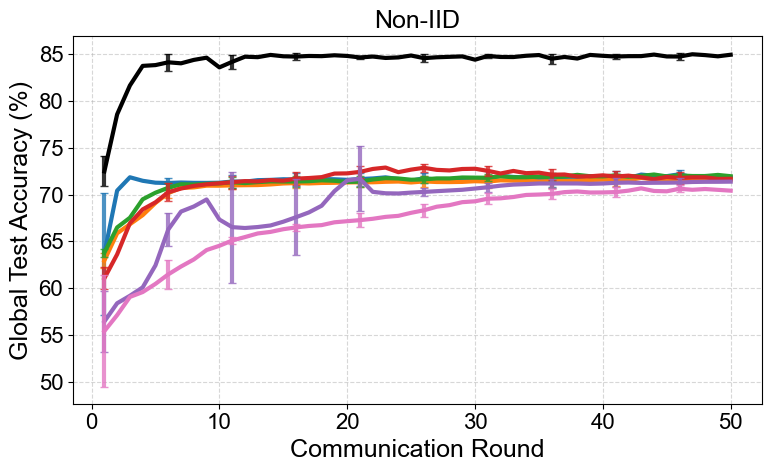

✓ Saved: /Users/mlsilab/Documents/Shuvo/UniCSL/results/revision 3 sq hinge/convergence_non_iid_hepmass.png


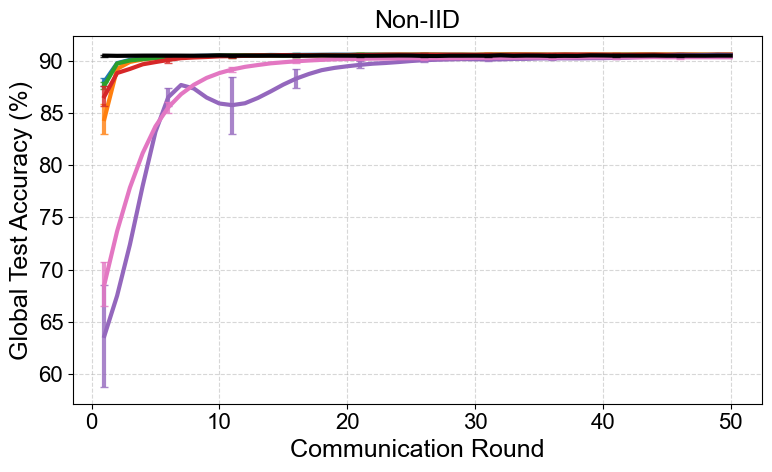

✓ Saved: /Users/mlsilab/Documents/Shuvo/UniCSL/results/revision 3 sq hinge/convergence_non_iid_magic_gamma_telescope.png


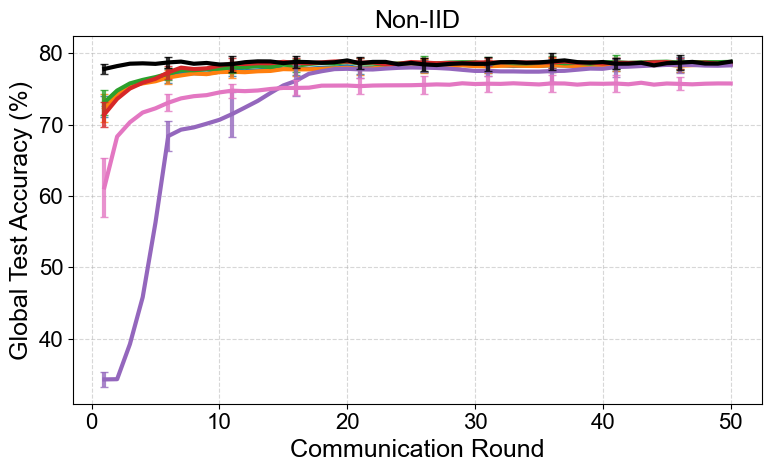

✓ Saved: /Users/mlsilab/Documents/Shuvo/UniCSL/results/revision 3 sq hinge/convergence_non_iid_susy.png


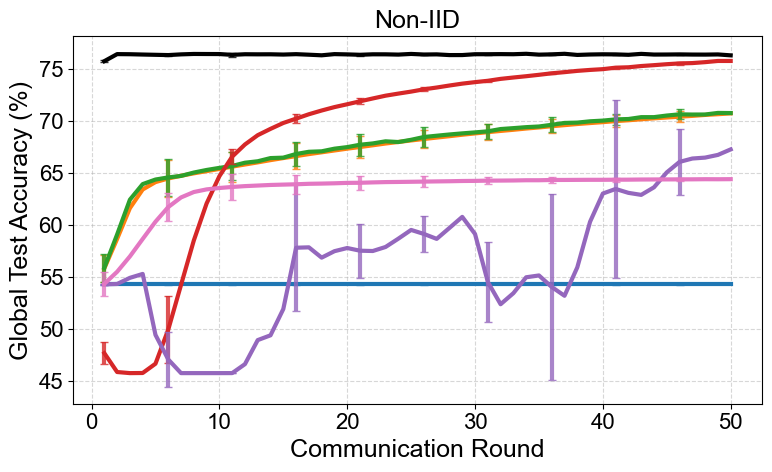

✓ Saved: /Users/mlsilab/Documents/Shuvo/UniCSL/results/revision 3 sq hinge/convergence_non_iid_corrupted_A9a.png


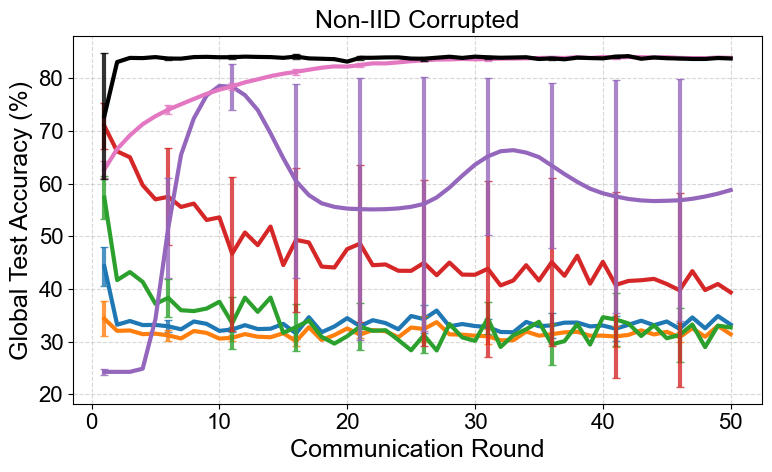

✓ Saved: /Users/mlsilab/Documents/Shuvo/UniCSL/results/revision 3 sq hinge/convergence_non_iid_corrupted_Run_or_walk_information.png


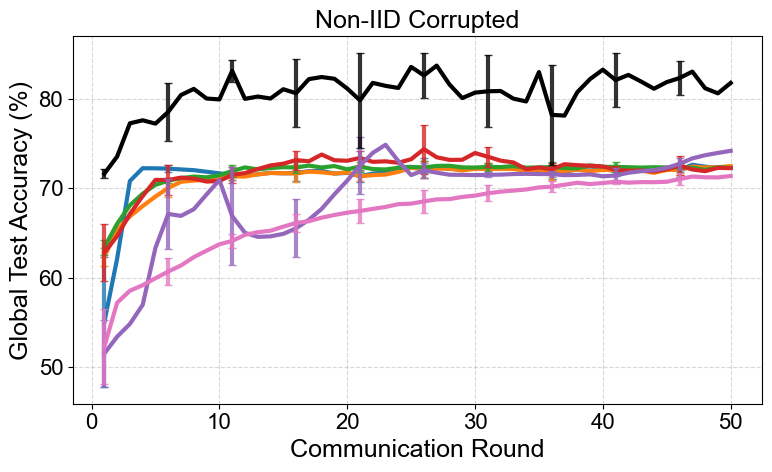

✓ Saved: /Users/mlsilab/Documents/Shuvo/UniCSL/results/revision 3 sq hinge/convergence_non_iid_corrupted_hepmass.png


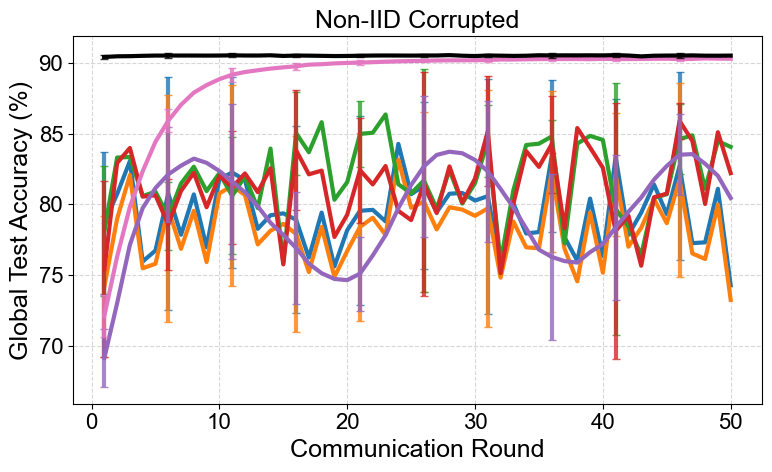

✓ Saved: /Users/mlsilab/Documents/Shuvo/UniCSL/results/revision 3 sq hinge/convergence_non_iid_corrupted_magic_gamma_telescope.png


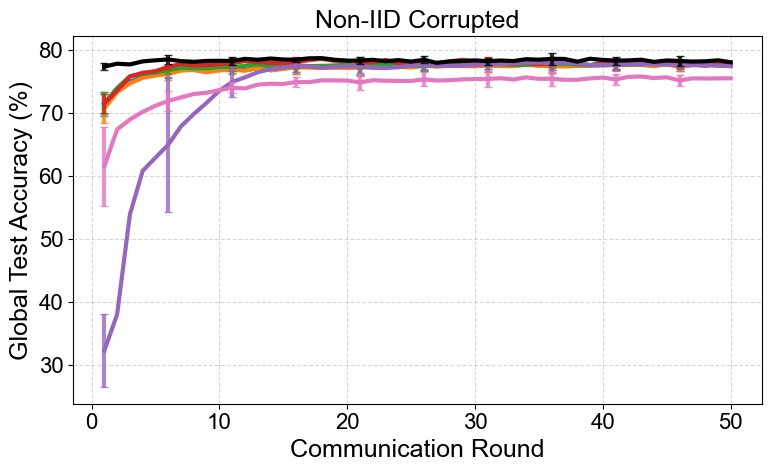

✓ Saved: /Users/mlsilab/Documents/Shuvo/UniCSL/results/revision 3 sq hinge/convergence_non_iid_corrupted_susy.png


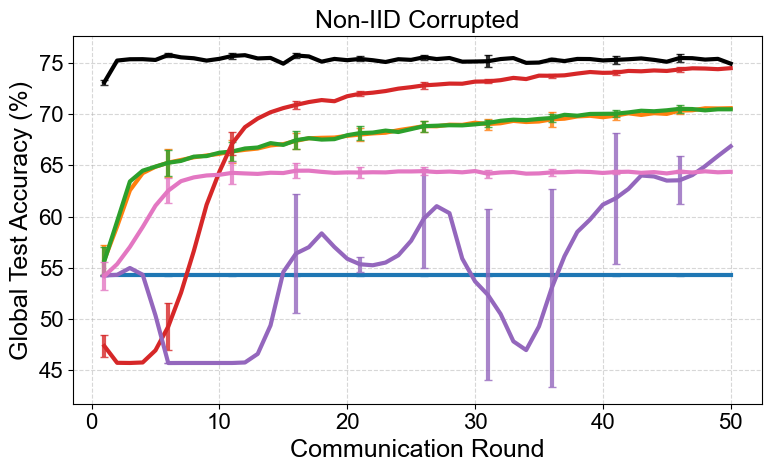


✓ All convergence plots generated!


In [32]:
# ============================================================
# CONVERGENCE PLOTS: Line plot with error bars — matched style
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# --- Style settings (matching your previous code) ---
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 16,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 16
})

error_interval = 5   # show error bars every N rounds

algo_display = {
    'fedavg':   ('FedAvg',   '#1f77b4'),
    'fedprox':  ('FedProx',  '#ff7f0e'),
    'scaffold': ('SCAFFOLD', '#2ca02c'),
    'feddyn':   ('FedDyn',   '#d62728'),
    'fedopt':   ('FedOpt',   '#9467bd'),
    'pfedme':   ('pFedMe',  '#e377c2'),
    'unicsl':   ('UniCSL',   '#000000'),
}

scenario_titles = {
    'iid':               'IID',
    'non_iid':           'Non-IID',
    'non_iid_corrupted': 'Non-IID Corrupted',
}

output_dir_plots = r'/Users/mlsilab/Documents/Shuvo/UniCSL/results/revision 3 sq hinge'

# --- Build per-round data: round_data[scenario][dataset][algo] = (n_seeds, 50) ---
round_data = {}

for scenario in scenarios:
    round_data[scenario] = {}
    for seed in seeds:
        df = data_all_seeds[scenario][seed]
        for dataset_name in df['Dataset'].unique():
            if dataset_name not in round_data[scenario]:
                round_data[scenario][dataset_name] = {algo: [] for algo in algorithms}
            dataset_df = df[(df['Dataset'] == dataset_name) & (df['Round'] != 'Average')]
            dataset_df = dataset_df.sort_values('Round')
            for algo_name, col_name in algorithms.items():
                if col_name in dataset_df.columns:
                    vals = dataset_df[col_name].values.astype(float)
                    round_data[scenario][dataset_name][algo_name].append(vals)

# Convert to numpy arrays
for scenario in scenarios:
    for dataset_name in round_data[scenario]:
        for algo_name in round_data[scenario][dataset_name]:
            arr = round_data[scenario][dataset_name][algo_name]
            if arr:
                round_data[scenario][dataset_name][algo_name] = np.array(arr)  # (n_seeds, n_rounds)

# --- Plot: one figure per (scenario × dataset) ---
for scenario in scenarios:
    datasets_sorted = sorted(round_data[scenario].keys())

    for dataset_name in datasets_sorted:
        plt.figure(figsize=(8, 5))

        for algo_name, (label, color) in algo_display.items():
            arr = round_data[scenario][dataset_name].get(algo_name)
            if arr is None or not isinstance(arr, np.ndarray) or arr.ndim < 2:
                continue

            mean = arr.mean(axis=0)           # (50,)
            std  = arr.std(axis=0)            # (50,)
            rounds = np.arange(1, len(mean) + 1)
            err_idx = np.arange(0, len(rounds), error_interval)

            plt.plot(
                rounds, mean,
                label=label,
                color=color,
                linewidth=3
            )
            plt.errorbar(
                rounds[err_idx], mean[err_idx], yerr=std[err_idx],
                fmt='none', ecolor=color,
                elinewidth=3, capsize=3, alpha=0.8
            )

        plt.xlabel("Communication Round", fontsize=18)
        plt.ylabel("Global Test Accuracy (%)", fontsize=18)
        plt.title(f'{scenario_titles[scenario]}', fontsize=18)
        plt.grid(True, linestyle="--", alpha=0.5)
        # plt.legend()
        plt.tight_layout()

        # Save
        safe_name = dataset_name.replace(' ', '_')
        save_path = os.path.join(output_dir_plots, f'convergence_{scenario}_{safe_name}.png')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'✓ Saved: {save_path}')
        plt.show()

print('\n✓ All convergence plots generated!')

In [33]:
# # ============================================================
# # STEP 1 — Save a standalone horizontal legend strip
# #           Add this ONCE before your plot loop.
# # ============================================================

# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# import os

# plt.rcParams.update({
#     "font.family": "Arial",
#     "font.size": 16,
#     "axes.labelsize": 16,
#     "axes.titlesize": 16,
#     "legend.fontsize": 16
# })

# algo_display = {
#     'fedavg':   ('FedAvg',   '#1f77b4'),
#     'fedprox':  ('FedProx',  '#ff7f0e'),
#     'scaffold': ('SCAFFOLD', '#2ca02c'),
#     'feddyn':   ('FedDyn',   '#d62728'),
#     'fedopt':   ('FedOpt',   '#9467bd'),
#     'pfedme':   ('pFedMe',  '#e377c2'),
#     'unicsl':   ('UniCSL',   '#000000'),
# }
# output_dir_plots = r'/Users/mlsilab/Documents/Shuvo/UniCSL/results/revision 3 sq hinge'
# # Build legend handles — solid line + label, matching your plot style
# handles = [
#     plt.Line2D(
#         [0], [0],
#         color=color,
#         linewidth=3,
#         label=label
#     )
#     for _, (label, color) in algo_display.items()
# ]

# # Figure height is just tall enough to hold one row of legend entries.
# # Width scales with number of algorithms — adjust ncol to force one row.
# fig_legend, ax_legend = plt.subplots(figsize=(len(algo_display) * 1.6, 0.55))
# ax_legend.axis('off')

# legend = ax_legend.legend(
#     handles=handles,
#     loc='center',
#     ncol=len(algo_display),     # all items in one horizontal row
#     frameon=True,
#     framealpha=1.0,
#     edgecolor='#cccccc',
#     handlelength=2.0,
#     handletextpad=0.6,
#     columnspacing=1.2,
#     fontsize=16,
# )

# fig_legend.tight_layout(pad=0.2)

# legend_path = os.path.join(output_dir_plots, 'legend_strip.png')
# fig_legend.savefig(legend_path, dpi=300, bbox_inches='tight')
# plt.close(fig_legend)
# print(f'✓ Saved legend strip: {legend_path}')


# # ============================================================
# # STEP 2 — Convergence plots, identical to yours but NO legend
# #           Replace your existing plot loop with this.
# # ============================================================

# error_interval = 5

# scenario_titles = {
#     'iid':               'IID',
#     'non_iid':           'Non-IID',
#     'non_iid_corrupted': 'Non-IID Corrupted',
# }

# for scenario in scenarios:
#     datasets_sorted = sorted(round_data[scenario].keys())

#     for dataset_name in datasets_sorted:
#         plt.figure(figsize=(8, 5))

#         for algo_name, (label, color) in algo_display.items():
#             arr = round_data[scenario][dataset_name].get(algo_name)
#             if arr is None or not isinstance(arr, np.ndarray) or arr.ndim < 2:
#                 continue

#             mean   = arr.mean(axis=0)
#             std    = arr.std(axis=0)
#             rounds  = np.arange(1, len(mean) + 1)
#             err_idx = np.arange(0, len(rounds), error_interval)

#             plt.plot(
#                 rounds, mean,
#                 color=color,
#                 linewidth=3
#                 # label intentionally omitted — legend is a separate file
#             )
#             plt.errorbar(
#                 rounds[err_idx], mean[err_idx], yerr=std[err_idx],
#                 fmt='none', ecolor=color,
#                 elinewidth=3, capsize=3, alpha=0.8
#             )

#         plt.xlabel("Communication Round", fontsize=18)
#         plt.ylabel("Global Test Accuracy (%)", fontsize=18)
#         plt.title(f'{scenario_titles[scenario]}', fontsize=18)
#         plt.grid(True, linestyle="--", alpha=0.5)
#         plt.tight_layout()

#         safe_name = dataset_name.replace(' ', '_')
#         save_path = os.path.join(output_dir_plots, f'convergence_{scenario}_{safe_name}.png')
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
#         print(f'✓ Saved: {save_path}')
#         plt.show()
#         plt.close()

# print('\n✓ All convergence plots generated!')
# print(f'✓ Legend strip saved separately → legend_strip.png')